# Chapter 4 — Baseline Forecasting & Model Evaluation (Code + Explanation)
4.1 Setup (Data + Visualization)

We start by creating the same dataset you described.

C:\Users\oadsa\AppData\Local\Temp\ipykernel_3668\356852342.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  date = pd.date_range(start='2023-01-01', periods=24, freq='M')


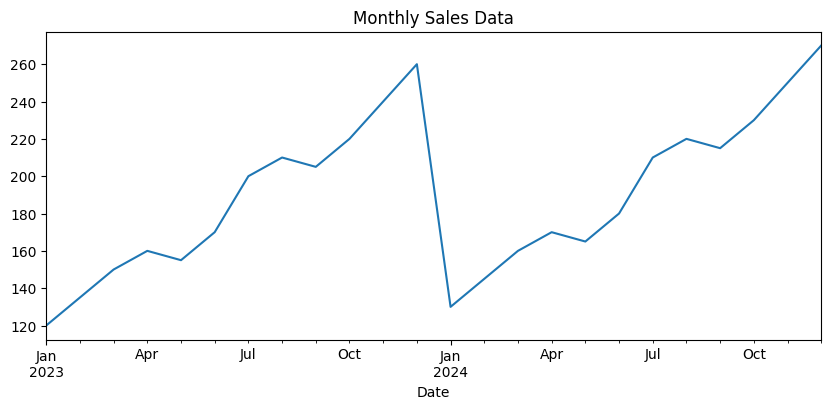

In [39]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Time index
date = pd.date_range(start='2023-01-01', periods=24, freq='M')

# Sales data (synthetic but realistic structure)
sales = [120,135,150,160,155,170,200,210,205,220,240,260,
         130,145,160,170,165,180,210,220,215,230,250,270]

# Create DataFrame
df = pd.DataFrame({'Date': date, 'Sales': sales})
df.set_index('Date', inplace=True)

# Plot
df['Sales'].plot(title="Monthly Sales Data", figsize=(10,4))
plt.show()

## 4.2 Train-Test Split (Simulating the Future)

In [40]:
train_size = 18

train = df.iloc[:train_size]
test = df.iloc[train_size:]

#### ACF PLot

<Figure size 600x400 with 0 Axes>

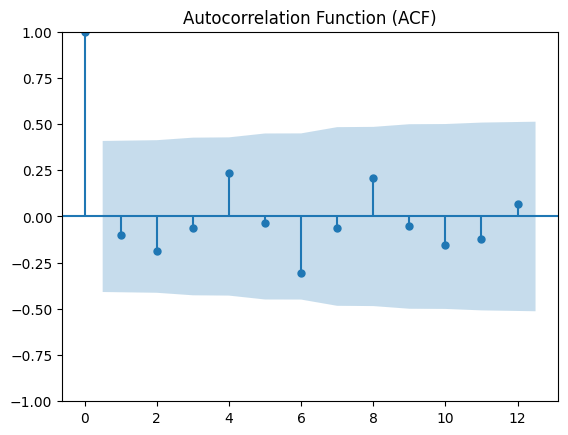

In [41]:

from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plot_acf(df['Sales'].diff().dropna(), lags=12)
plt.title("Autocorrelation Function (ACF)")
plt.show()

### PACF Plot

<Figure size 600x400 with 0 Axes>

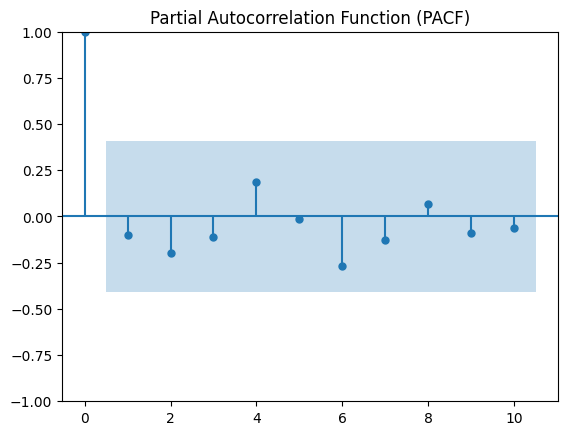

In [43]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plot_pacf(df['Sales'].diff().dropna(), lags=10)
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()


## 4.3 Baseline Model 1 — Naive Forecast
Idea: “Tomorrow = Today”

In [ ]:
df['Naive_Forecast'] = df['Sales'].shift(1)

## 4.4 Baseline Model 2 — Seasonal Naive
Idea: “This month behaves like the same month last year”

Since we have monthly data, we use lag = 12.

In [ ]:
season_length = 12
df['Seasonal_Naive'] = df['Sales'].shift(season_length)

## 4.5 Baseline Model 3 — Moving Average
Idea:

“Future is the average of recent past”

In [ ]:
df['Moving_Avg'] = df['Sales'].rolling(window=3).mean()

## 4.6 Evaluation Setup (Core Step)

We only evaluate on test data.

In [ ]:
test_df = df.iloc[train_size:]

## 4.7 Evaluation Metrics

We define MAE, RMSE, MAPE manually (for clarity).

In [ ]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

## 4.8 Align Predictions with Test Data

Because of shifting, we must align properly:

In [ ]:
test_df = df.iloc[train_size:].copy()

y_true = test_df['Sales']

### Predictions:

In [ ]:
naive_pred = test_df['Naive_Forecast']
seasonal_pred = test_df['Seasonal_Naive']
moving_pred = test_df['Moving_Avg']

## 4.9 Handling Missing Values

Some models (like moving average) create NaN values.

In [ ]:
moving_pred = moving_pred.dropna()
y_true_ma = y_true.loc[moving_pred.index]

## 4.10 Compute Metrics
Naive Model

In [ ]:
print("Naive Model:")
print("MAE:", mae(y_true[1:], naive_pred[1:]))
print("RMSE:", rmse(y_true[1:], naive_pred[1:]))
print("MAPE:", mape(y_true[1:], naive_pred[1:]))

Naive Model:
MAE: 14.0
RMSE: 15.165750888103101
MAPE: 5.760036495729115


## Seasonal Naive Model

In [ ]:
print("\nSeasonal Naive Model:")
print("MAE:", mae(y_true, seasonal_pred))
print("RMSE:", rmse(y_true, seasonal_pred))
print("MAPE:", mape(y_true, seasonal_pred))


Seasonal Naive Model:
MAE: 10.0
RMSE: 10.0
MAPE: 4.335008648119534


## Moving Average Model

In [ ]:
print("\nMoving Average Model:")
print("MAE:", mae(y_true_ma, moving_pred))
print("RMSE:", rmse(y_true_ma, moving_pred))
print("MAPE:", mape(y_true_ma, moving_pred))


Moving Average Model:
MAE: 14.722222222222223
RMSE: 16.87371394276382
MAPE: 6.3074081045095545


## 4.11 Visual Comparison

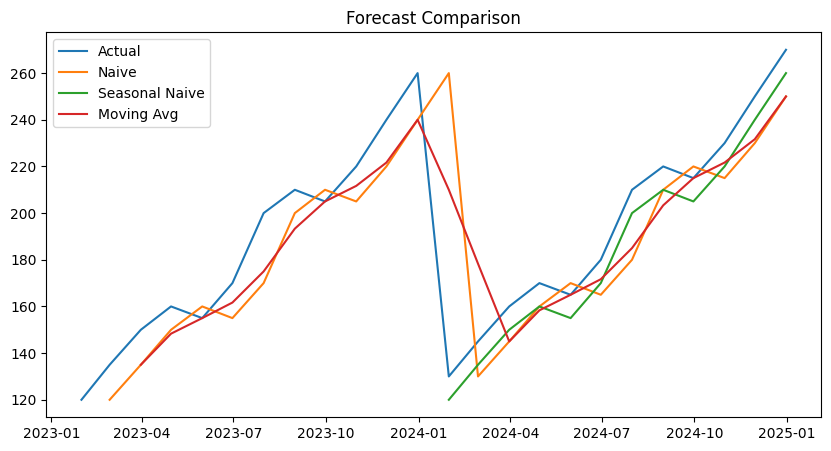

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(df['Sales'], label="Actual")
plt.plot(df['Naive_Forecast'], label="Naive")
plt.plot(df['Seasonal_Naive'], label="Seasonal Naive")
plt.plot(df['Moving_Avg'], label="Moving Avg")

plt.legend()
plt.title("Forecast Comparison")
plt.show()

### Final Summary (What You Just Built)

You have now created a complete forecasting pipeline:

1. Data understanding
2. Train-test split
3. Baseline models
4. Prediction generation
5. Evaluation metrics
6. Model comparison